## Part 1: Word Embeddings
### 1. TF-IDF and PMI Weighted Representations
#### 1.1 TF-IDF Weighting

In [2]:
import numpy as np
from collections import Counter
import json

def build_vocabulary(filepath, vocab_size=10000):
    """Reads corpus, builds top-K vocabulary, and maps <UNK>."""
    documents = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            doc = line.strip().split()
            if doc:
                documents.append(doc)
                
    all_tokens = [token for doc in documents for token in doc]
    token_counts = Counter(all_tokens)
    top_tokens = [token for token, count in token_counts.most_common(vocab_size)]
    
    word2idx = {"<UNK>": 0}
    for idx, token in enumerate(top_tokens, start=1):
        word2idx[token] = idx
        
    idx2word = {idx: word for word, idx in word2idx.items()}
        
    with open('embeddings/word2idx.json', 'w', encoding='utf-8') as f:
        json.dump(word2idx, f, ensure_ascii=False, indent=4)
        
    return documents, word2idx, idx2word

def compute_tfidf(documents, word2idx):
    """Computes TF-IDF matrix."""
    N = len(documents)
    V = len(word2idx)
    
    tf_matrix = np.zeros((V, N), dtype=np.float32)
    df_counts = np.zeros(V, dtype=np.float32)
    
    for d_idx, doc in enumerate(documents):
        unique_words_in_doc = set()
        for word in doc:
            w_idx = word2idx.get(word, 0)
            tf_matrix[w_idx, d_idx] += 1
            unique_words_in_doc.add(w_idx)
            
        for w_idx in unique_words_in_doc:
            df_counts[w_idx] += 1
            
    idf_vector = np.log(N / (1 + df_counts))
    tfidf_matrix = tf_matrix * idf_vector[:, np.newaxis]
    
    np.save('embeddings/tfidf_matrix.npy', tfidf_matrix)
    return tfidf_matrix

def report_top_tfidf_words(tfidf_matrix, idx2word, metadata_filepath):
    """Identifies top-10 most discriminative words per topic."""
    # Note: Requires loading your Metadata.json to map doc_idx to topics
    with open(metadata_filepath, 'r', encoding='utf-8') as f:
        metadata = json.load(f)
    
    # Assuming metadata contains a list of topic labels corresponding to document order
    topic_labels = metadata['topics'] 
    unique_topics = set(topic_labels)
    
    print("Top 10 Discriminative Words per Topic:")
    for topic in unique_topics:
        # Get document indices belonging to this topic
        doc_indices = [i for i, label in enumerate(topic_labels) if label == topic]
        
        # Calculate mean TF-IDF score for each word across documents in this topic
        topic_tfidf_scores = np.mean(tfidf_matrix[:, doc_indices], axis=1)
        
        # Get top 10 indices (ignoring <UNK> at index 0)
        top_10_indices = topic_tfidf_scores.argsort()[-11:][::-1]
        top_10_words = [idx2word[idx] for idx in top_10_indices if idx != 0][:10]
        
        print(f"- {topic}: {', '.join(top_10_words)}")

# Execution for 1.1
documents, word2idx, idx2word = build_vocabulary('cleaned.txt', vocab_size=10000)
tfidf_matrix = compute_tfidf(documents, word2idx)
# report_top_tfidf_words(tfidf_matrix, idx2word, 'Metadata.json') # Uncomment when Metadata is mapped

#### 1.2 Pointwise Mutual Information (PMI)

C:\Users\USR\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USR\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USR\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


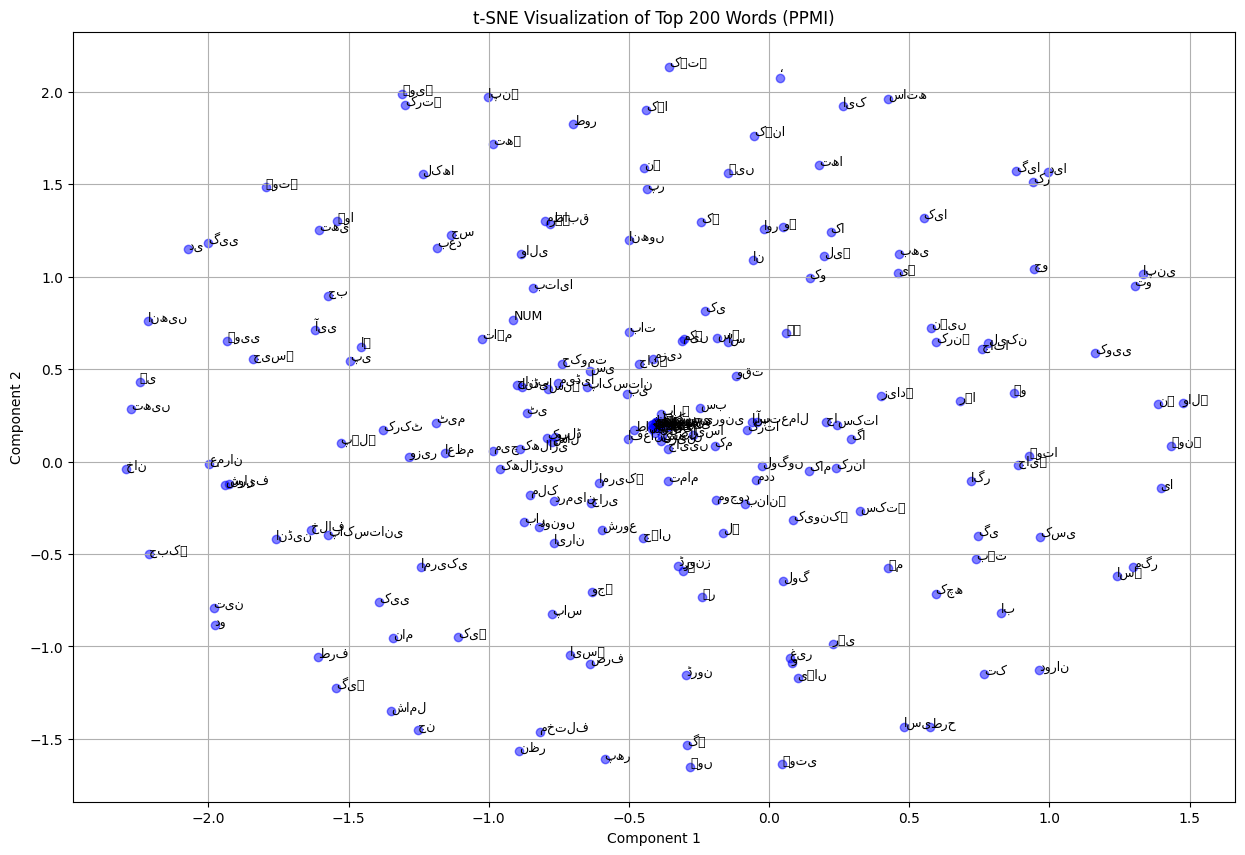

In [3]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def compute_ppmi(documents, word2idx, window_size=5):
    """Builds co-occurrence matrix and computes PPMI."""
    V = len(word2idx)
    co_occurrence = np.zeros((V, V), dtype=np.float32)
    
    # 1. Build symmetric co-occurrence matrix
    for doc in documents:
        doc_indices = [word2idx.get(w, 0) for w in doc]
        length = len(doc_indices)
        
        for i, target_word in enumerate(doc_indices):
            # Define context window boundaries
            start = max(0, i - window_size)
            end = min(length, i + window_size + 1)
            
            for j in range(start, end):
                if i != j:
                    context_word = doc_indices[j]
                    co_occurrence[target_word, context_word] += 1
                    
    # 2. Calculate probabilities for PPMI
    total_co_occurrences = np.sum(co_occurrence)
    word_totals = np.sum(co_occurrence, axis=1)
    
    # To avoid division by zero, add a tiny epsilon to word_totals
    epsilon = 1e-8
    P_wc = co_occurrence / total_co_occurrences
    P_w = (word_totals / total_co_occurrences) + epsilon
    
    # Expected probabilities P(w1) * P(w2)
    P_w_expected = np.outer(P_w, P_w)
    
    # 3. Calculate PPMI: max(0, log2(P(w,c) / (P(w)*P(c))))
    with np.errstate(divide='ignore', invalid='ignore'):
        # Only compute log where P_wc is non-zero
        pmi = np.log2(P_wc / P_w_expected)
        ppmi_matrix = np.maximum(pmi, 0) # Apply positive constraint
        ppmi_matrix[np.isnan(ppmi_matrix)] = 0 # Handle NaNs from zero division
        
    np.save('embeddings/ppmi_matrix.npy', ppmi_matrix)
    return ppmi_matrix

def visualize_tsne(matrix, word2idx, idx2word, num_words=200):
    """Produces 2-D t-SNE visualization for top frequent tokens."""
    # Extract the top 'num_words' (skipping <UNK> at index 0)
    top_vectors = matrix[1:num_words+1]
    top_words = [idx2word[i] for i in range(1, num_words+1)]
    
    # Run t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    reduced_vectors = tsne.fit_transform(top_vectors)
    
    # Plotting
    plt.figure(figsize=(15, 10))
    plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1], c='blue', alpha=0.5)
    
    for i, word in enumerate(top_words):
        plt.annotate(word, (reduced_vectors[i, 0], reduced_vectors[i, 1]), fontsize=9)
        
    plt.title(f"t-SNE Visualization of Top {num_words} Words (PPMI)")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.grid(True)
    plt.show()

# Execution for 1.2
ppmi_matrix = compute_ppmi(documents, word2idx, window_size=5)
visualize_tsne(ppmi_matrix, word2idx, idx2word, num_words=200)